In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("SELECT * FROM bank_churn", engine)
print("Строк:", len(df))
print("Колонок:", len(df.columns))
df.head(3)

Строк: 80000
Колонок: 26


,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,...,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,...,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,...,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,...,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4


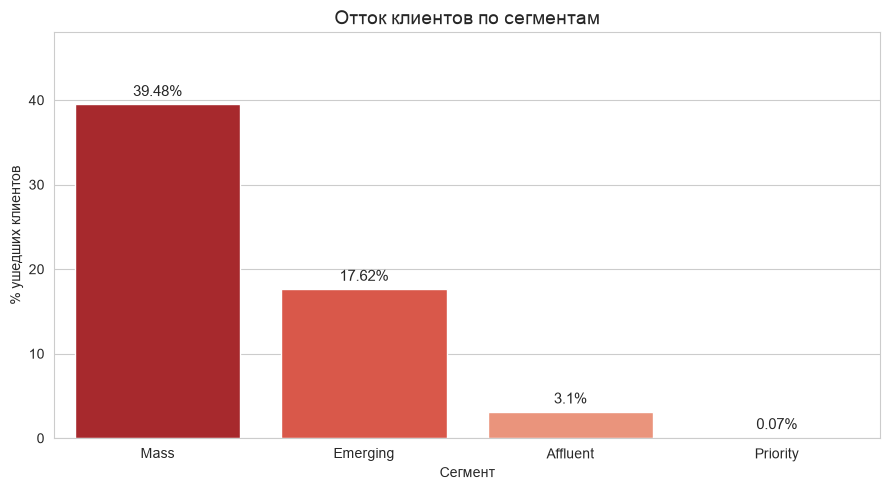

In [4]:
segment_data = df.groupby("customer_segment").agg(
    всего=("exit", "count"),
    ушло=("exit", "sum")
).reset_index()
segment_data["процент_оттока"] = (100 * segment_data["ушло"] / segment_data["всего"]).round(2)
segment_data = segment_data.sort_values("процент_оттока", ascending=False).reset_index(drop=True)
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=segment_data, x="customer_segment", y="процент_оттока",
                 hue="customer_segment", palette="Reds_r", legend=False)
for i, row in segment_data.iterrows():
    ax.text(i, row["процент_оттока"] + 1, f'{row["процент_оттока"]}%', ha="center", fontsize=11)
plt.title("Отток клиентов по сегментам", fontsize=14)
plt.xlabel("Сегмент")
plt.ylabel("% ушедших клиентов")
plt.ylim(0, 48)
plt.tight_layout()
plt.show()

## Отток по сегментам

Mass — единственный сегмент с критическим уровнем оттока: 39.48% против 17.62% (Emerging), 3.10% (Affluent) и 0.07% (Priority). Разница между Mass и Priority — более чем в 560 раз.

При этом Mass составляет 27% клиентской базы, но даёт 59% всех уходов. Это ключевой сегмент для программ удержания.

Наблюдение не объясняет причину: сегмент может быть как независимым фактором, так и прокси для других признаков (канал, лояльность). Проверка — в следующих разделах.

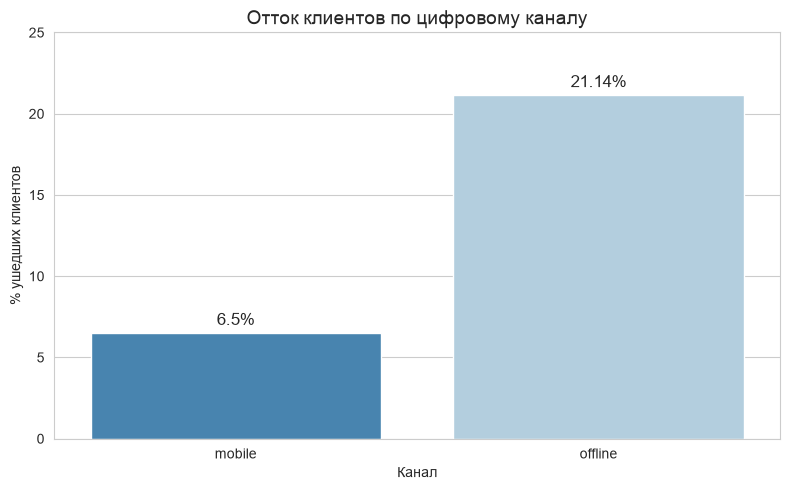

In [5]:
channel_data = df.groupby("digital_behavior").agg(
    всего=("exit", "count"),
    ушло=("exit", "sum")
).reset_index()
channel_data["процент_оттока"] = (100 * channel_data["ушло"] / channel_data["всего"]).round(2)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=channel_data, x="digital_behavior", y="процент_оттока",
                 hue="digital_behavior", palette="Blues_r", legend=False)
for i, row in channel_data.iterrows():
    ax.text(i, row["процент_оттока"] + 0.5, f'{row["процент_оттока"]}%', ha="center", fontsize=12)
plt.title("Отток клиентов по цифровому каналу", fontsize=14)
plt.xlabel("Канал")
plt.ylabel("% ушедших клиентов")
plt.ylim(0, 25)
plt.tight_layout()
plt.show()

## Отток по цифровому каналу

Клиенты без мобильного приложения уходят в 3.25 раза чаще: 21.14% против 6.50%. Это самый сильный эффект из всех, что мы проверили — сильнее сегмента и лояльности.

Разница сохраняется независимо от других факторов, что делает цифровой канал ключевым рычагом удержания. Однако нужно проверить обратную гипотезу: возможно, приложением пользуются уже лояльные клиенты, а не наоборот.

Проверим это через пересечение с сегментами в следующем графике.

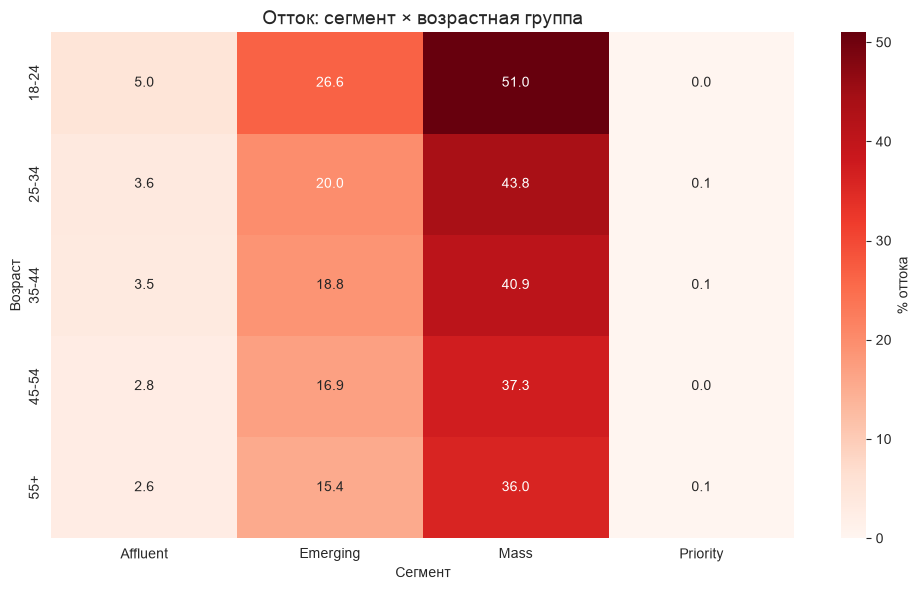

In [7]:
df["возрастная_группа"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55+"]
)
pivot = df.pivot_table(
    index="возрастная_группа",
    columns="customer_segment",
    values="exit",
    aggfunc="mean",
    observed=True
) * 100
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% оттока"})
plt.title("Отток: сегмент × возрастная группа", fontsize=14)
plt.xlabel("Сегмент")
plt.ylabel("Возраст")
plt.tight_layout()
plt.show()

## Отток: сегмент × возрастная группа

Самый высокий отток — Mass + 18-24: **51.0%**. Каждый второй молодой клиент массового сегмента уходит. Даже в 55+ Mass даёт 36.0%, что вдвое выше среднего по банку.

Возраст работает как усилитель только в Mass и Emerging: чем моложе, тем выше отток. В Affluent и Priority возраст не влияет — 0-5% в любой группе.

Это подтверждает, что сегмент — первичный фактор, а возраст — вторичный. Приоритет удержания: молодые клиенты в Mass.

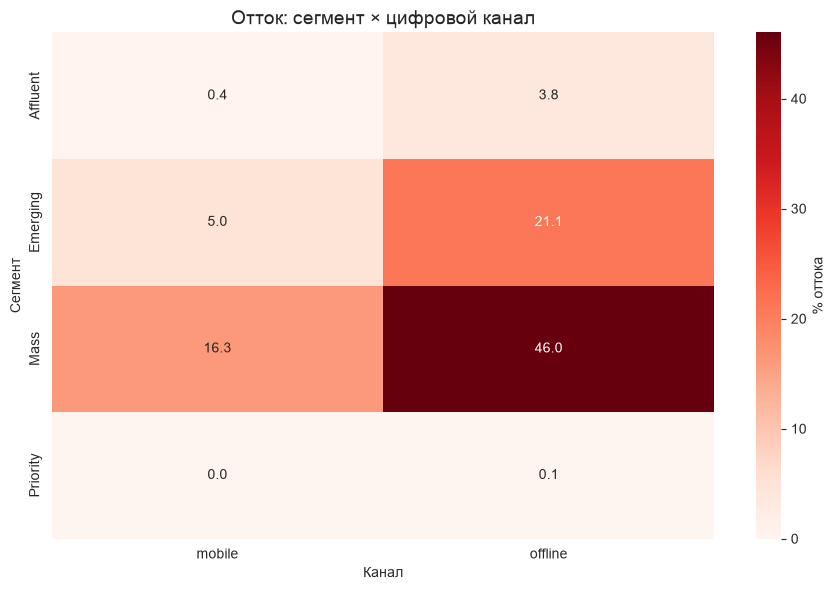

In [8]:
pivot2 = df.pivot_table(
    index="customer_segment",
    columns="digital_behavior",
    values="exit",
    aggfunc="mean",
    observed=True
) * 100
plt.figure(figsize=(9, 6))
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% оттока"})
plt.title("Отток: сегмент × цифровой канал", fontsize=14)
plt.xlabel("Канал")
plt.ylabel("Сегмент")
plt.tight_layout()
plt.show()

## Отток: сегмент × цифровой канал

Ключевое открытие: Mass + offline даёт **46.0%** — почти каждый второй клиент уходит. Mass + mobile — 16.3%, в 2.8 раза меньше. Приложение не решает проблему Mass полностью, но заметно её смягчает.

В Emerging эффект сильнее: 5.0% (mobile) против 21.1% (offline) — разница в 4.2 раза. У Affluent и Priority отток низкий в любом канале, но и там mobile лучше offline.

Это подтверждает гипотезу: цифровой канал — самостоятельный драйвер удержания, а не прокси для сегмента.

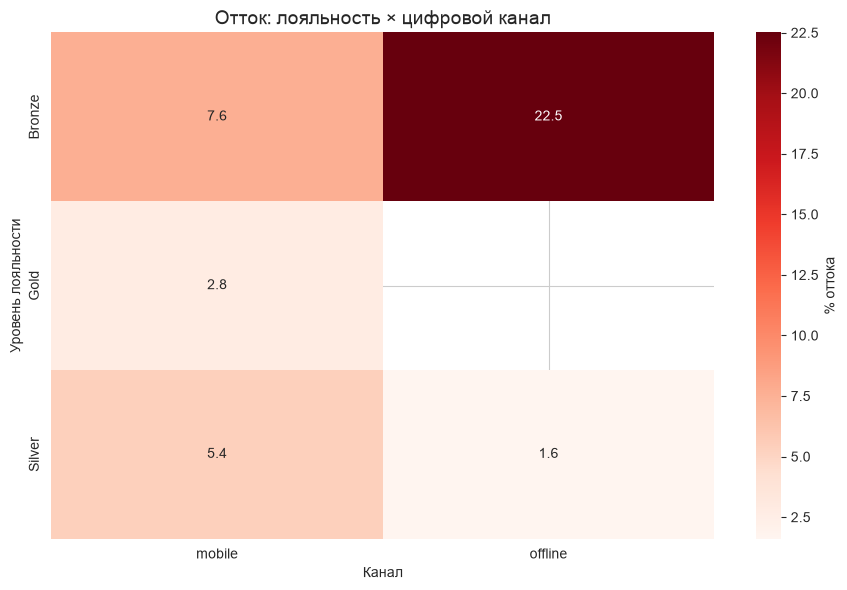

In [9]:
pivot3 = df.pivot_table(
    index="loyalty_level",
    columns="digital_behavior",
    values="exit",
    aggfunc="mean",
    observed=True
) * 100
plt.figure(figsize=(9, 6))
sns.heatmap(pivot3, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% оттока"})
plt.title("Отток: лояльность × цифровой канал", fontsize=14)
plt.xlabel("Канал")
plt.ylabel("Уровень лояльности")
plt.tight_layout()
plt.show()

## Отток: лояльность × цифровой канал

Внутри Bronze разница сохраняется: 7.6% (mobile) против 22.5% (offline) — в 3 раза. Канал влияет на отток независимо от уровня лояльности.

Все 1771 Gold-клиентов только в mobile. Offline-группы нет не из-за пропуска данных, а структурно.

Silver — исключение, требует отдельного анализа.

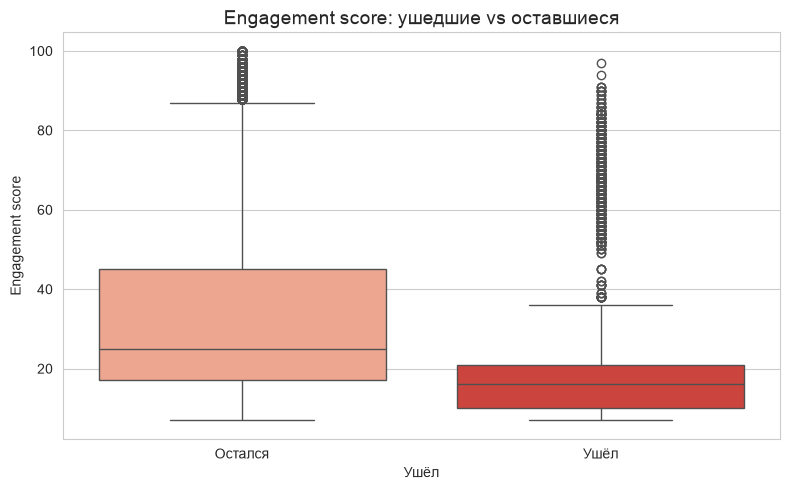

         count   mean    std  min   25%   50%   75%    max
exit                                                      
False  65600.0  34.31  24.18  7.0  17.0  25.0  45.0  100.0
True   14400.0  19.94  15.10  7.0  10.0  16.0  21.0   97.0


In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="exit", y="engagement_score", hue="exit", palette="Reds", legend=False)
plt.title("Engagement score: ушедшие vs оставшиеся", fontsize=14)
plt.xlabel("Ушёл")
plt.ylabel("Engagement score")
plt.xticks([0, 1], ["Остался", "Ушёл"])
plt.tight_layout()
plt.show()
print(df.groupby("exit")["engagement_score"].describe().round(2))

## Engagement score: ушедшие vs оставшиеся

Медиана у ушедших — 16 против 25 у оставшихся. Разница в 1.6 раза. 75% ушедших имеют score ≤ 21, тогда как у оставшихся тот же квартиль — 45.

Engagement — устойчивый предиктор оттока, но не абсолютный: есть клиенты с score 90+, которые всё равно ушли. Значит, помимо вовлечённости действуют другие факторы.

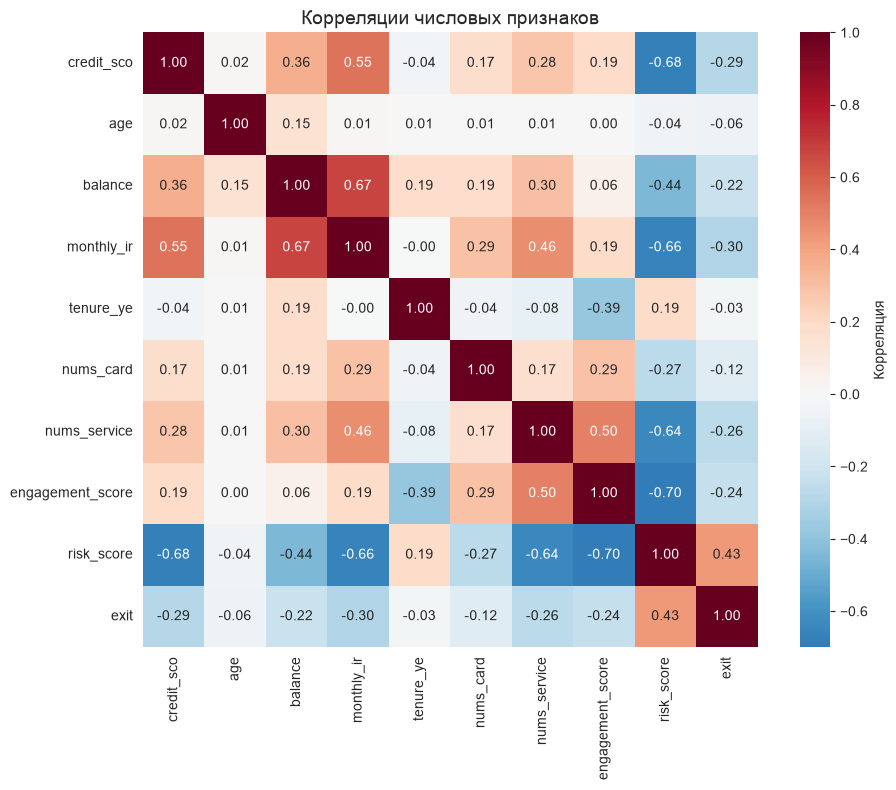

In [14]:
numeric_cols = ["credit_sco", "age", "balance", "monthly_ir",
                "tenure_ye", "nums_card", "nums_service",
                "engagement_score", "risk_score"]
corr = df[numeric_cols + ["exit"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            cbar_kws={"label": "Корреляция"})
plt.title("Корреляции числовых признаков", fontsize=14)
plt.tight_layout()
plt.show()

## Корреляции числовых признаков

Главный числовой предиктор оттока — risk_score (r = 0.43): чем выше риск, тем выше вероятность ухода. В обратную сторону работают доход (r = −0.30), кредитный скор (−0.29) и число сервисов (−0.26).

Возраст и стаж практически не связаны с оттоком (|r| < 0.07). Это противоречит распространённой гипотезе, что «старые клиенты лояльнее». В этих данных такого эффекта нет.

Отдельно стоит отметить сильную корреляцию risk_score ↔ engagement_score = −0.70: вовлечённые клиенты имеют низкий риск. Возможно, эти признаки частично дублируют друг друга — учесть при построении ML-модели.